<a href="https://colab.research.google.com/github/ThumulaRumesh/Smart-Homes---Indoor-Scene-Recognition-from-Images---CNN/blob/develop/06_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Imports
2. Dataset paths and settings
3. Load datasets
4. ResNet50 preprocessing
5. Prefetch
6. Load pretrained ResNet50
7. Build classification model
8. Check model
9. Compile
10. Callbacks
11. Train
12. Learning curves
13. Initial test evaluation
14. Load best checkpoint
15. Final test evaluation
16. Classification report
17. Confusion matrix
18. Final results

ResNet50 requires preprocessing before the image enters the pretrained network. Keras specifically says ResNet inputs should go through preprocess_input, which converts RGB to BGR and zero-centers the channels using ImageNet statistics.

Step 1 — Imports

In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

Step 2 — Dataset paths and classes

In [2]:
dataset_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Selected Classes 500"

classes = [
    "kitchen",
    "bedroom",
    "bar",
    "livingroom",
    "warehouse"
]

image_size = (224, 224)
batch_size = 32

train_dir = os.path.join(dataset_dir, "train")
validation_dir = os.path.join(dataset_dir, "validation")
test_dir = os.path.join(dataset_dir, "test")

print("Dataset exists:", os.path.exists(dataset_dir))
print("Training directory exists:", os.path.exists(train_dir))
print("Validation directory exists:", os.path.exists(validation_dir))
print("Test directory exists:", os.path.exists(test_dir))

Dataset exists: True
Training directory exists: True
Validation directory exists: True
Test directory exists: True


Step 3 — Load the same datasets

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

print("Class names:", train_ds.class_names)

print(
    "Training batches:",
    tf.data.experimental.cardinality(train_ds).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_ds).numpy()
)

print(
    "Test batches:",
    tf.data.experimental.cardinality(test_ds).numpy()
)

Found 2500 files belonging to 5 classes.
Found 482 files belonging to 5 classes.
Found 484 files belonging to 5 classes.
Class names: ['kitchen', 'bedroom', 'bar', 'livingroom', 'warehouse']
Training batches: 79
Validation batches: 16
Test batches: 16


**Important ResNet50 preprocessing**

Unlike EfficientNetB0 and ConvNeXt-Tiny, ResNet50 requires model-specific preprocessing. Keras specifies that preprocess_input converts RGB images to BGR and zero-centers the colour channels using ImageNet statistics, without scaling.

In this notebook, ResNet50 preprocessing is applied to the datasets before the images are passed to the pretrained network.

The original image files remain unchanged. The dataset tensors are converted using preprocess_input before training, validation, and testing.

This ensures that the same ResNet50 preprocessing is applied consistently to all three datasets.

Step 4 — ResNet50 preprocessing

In [4]:
def preprocess_resnet(image, label):
    image = preprocess_input(image)
    return image, label


train_ds = train_ds.map(
    preprocess_resnet,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.map(
    preprocess_resnet,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    preprocess_resnet,
    num_parallel_calls=tf.data.AUTOTUNE
)

print("ResNet50 preprocessing configured.")

ResNet50 preprocessing configured.


Step 5 — Prefetch

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Prefetching configured.")

Prefetching configured.


Step 6 — Load ResNet50

In [6]:
base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("ResNet50 loaded successfully.")
print("Base model trainable:", base_model.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 loaded successfully.
Base model trainable: False


Step 7 — Build the classification model

In [7]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    5,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

print("ResNet50 classification model created successfully.")

ResNet50 classification model created successfully.


Step 8 — Check the model

In [8]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Step 9 — Compile

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Step 10 — Callbacks

In [10]:
checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/resnet50_newclasses.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks configured.")

Callbacks configured.


Step 11 — Train

In [11]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 433s 5s/step - accuracy: 0.7500 - loss: 0.6557 - val_accuracy: 0.8734 - val_loss: 0.3755
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - accuracy: 0.8796 - loss: 0.3125 - val_accuracy: 0.8714 - val_loss: 0.3305
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 252ms/step - accuracy: 0.9068 - loss: 0.2529 - val_accuracy: 0.8734 - val_loss: 0.3158
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 253ms/step - accuracy: 0.9196 - loss: 0.2228 - val_accuracy: 0.8859 - val_loss: 0.3259
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 268ms/step - accuracy: 0.9316 - loss: 0.1916 - val_accuracy: 0.8921 - val_loss: 0.3080
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 248ms/step - accuracy: 0.9344 - loss: 0.1830 - val_accuracy: 0.8880 - val_loss: 0.3011
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 23s 281ms/step - accuracy: 0.9496 - loss: 0.1515 - val_accuracy: 0.8776 - val_loss: 0.3350
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 230ms/step - accuracy: 0.9512 - loss: 0.1414 - val_accura

Step 12 — Plot learning curves

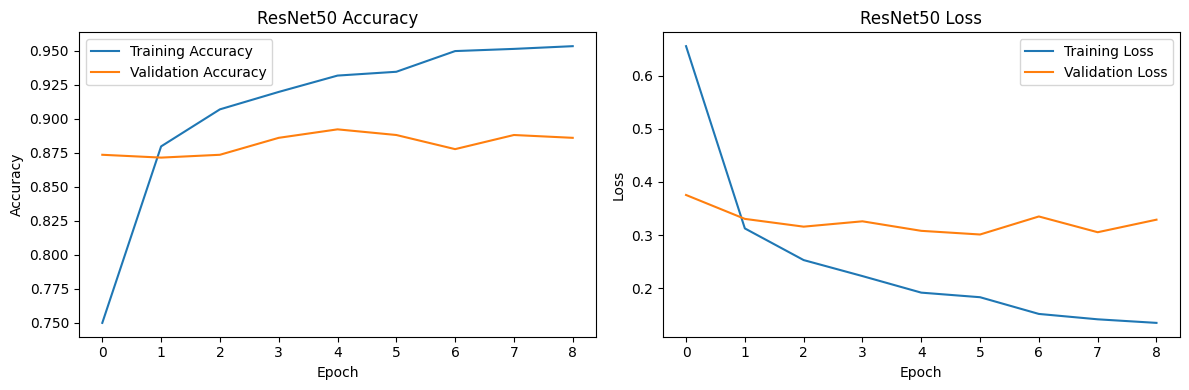

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Loss")
plt.legend()

plt.tight_layout()
plt.show()

Step 13 — Initial test evaluation

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 84s 5s/step - accuracy: 0.9050 - loss: 0.2728
Test Loss: 0.2727667987346649
Test Accuracy: 0.9049586653709412


Step 14 — Load the best checkpoint

In [14]:
best_model = tf.keras.models.load_model(
    checkpoint_path
)

print("Best ResNet50 model loaded successfully.")

Best ResNet50 model loaded successfully.


Step 15 — Final test evaluation

In [15]:
test_loss, test_accuracy = best_model.evaluate(test_ds)

print("Best ResNet50 Test Loss:", test_loss)
print("Best ResNet50 Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step - accuracy: 0.9050 - loss: 0.2728
Best ResNet50 Test Loss: 0.2727667987346649
Best ResNet50 Test Accuracy: 0.9049586653709412


Step 16 — Classification report

In [16]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
))

              precision    recall  f1-score   support

     kitchen     0.9615    0.9009    0.9302       111
     bedroom     0.8302    0.8800    0.8544       100
         bar     0.9667    0.9560    0.9613        91
  livingroom     0.8224    0.8302    0.8263       106
   warehouse     0.9740    0.9868    0.9804        76

    accuracy                         0.9050       484
   macro avg     0.9110    0.9108    0.9105       484
weighted avg     0.9069    0.9050    0.9055       484



Step 17 — Confusion matrix

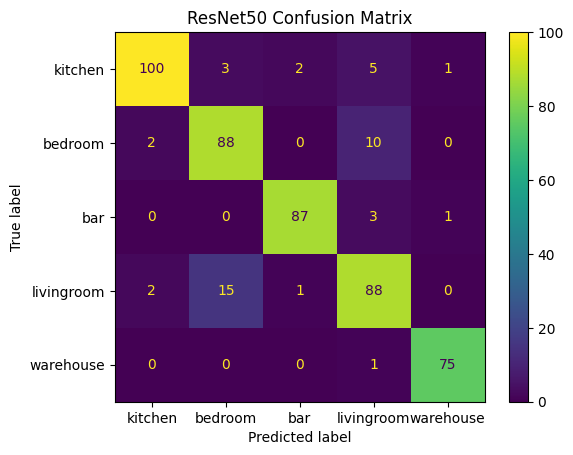

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()

plt.title("ResNet50 Confusion Matrix")
plt.show()

Step 18 — Final results

In [18]:
correct_predictions = sum(
    np.array(y_true) == np.array(y_pred)
)

incorrect_predictions = sum(
    np.array(y_true) != np.array(y_pred)
)

print("ResNet50 Final Results")
print("----------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Incorrect Predictions: {incorrect_predictions}")

ResNet50 Final Results
----------------------------
Test Loss: 0.2728
Test Accuracy: 90.4959%
Correct Predictions: 438
Incorrect Predictions: 46


Step 19 — Save ResNet50 results

In [20]:
results_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results"

os.makedirs(results_dir, exist_ok=True)

In [21]:
import json

report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4,
    output_dict=True
)

cm = confusion_matrix(y_true, y_pred)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_loss = float(np.min(history.history["val_loss"]))

resnet_results = {
    "model": "ResNet50",

    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),

    "correct_predictions": int(correct_predictions),
    "incorrect_predictions": int(incorrect_predictions),

    "total_parameters": int(model.count_params()),
    "trainable_parameters": int(
        np.sum([np.prod(v.shape) for v in model.trainable_weights])
    ),
    "non_trainable_parameters": int(
        np.sum([np.prod(v.shape) for v in model.non_trainable_weights])
    ),

    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "epochs_completed": len(history.history["loss"]),

    "classes": classes,

    "classification_report": report,

    "confusion_matrix": cm.tolist(),

    "history": {
        "accuracy": [float(x) for x in history.history["accuracy"]],
        "val_accuracy": [float(x) for x in history.history["val_accuracy"]],
        "loss": [float(x) for x in history.history["loss"]],
        "val_loss": [float(x) for x in history.history["val_loss"]]
    }
}

resnet_results_path = os.path.join(
    results_dir,
    "resnet50_results.json"
)

with open(resnet_results_path, "w") as f:
    json.dump(resnet_results, f, indent=4)

print("ResNet50 results saved:")
print(resnet_results_path)

ResNet50 results saved:
/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results/resnet50_results.json
